# Obsługa ROS Topics

## Wprowadzenie - polecenia w terminalu
ROS Topics używane są do komunikacji rozgłoszeniowej. Nie ma znaczenia kto jest nadawcą, a kto odbiorcą wiadomości. Za kodowanie przesyłanej wiadomości odpowiada **Publisher**, a za rozkodowanie **Subscriber**. Typy wiadomości przechowywane są w katalogu srv, a rozszerzenie wiadomości to .msg.

### Struktura wiadomości

Z lewej strony należy podać typ wiadomości ROS. Mogą być one bardziej złożone i składać się z już utworzonych wiadomości (ROS msg). Z prawej strony podawana jest nazwa pola.

Typ wiadomości to nazwa paczki + nazwa_wiadomosci.msg. Wyświetlenie przykładowej wiadomości znajdującej się w paczce tsr_materials:

In [ ]:
!rosmsg info pkg_tsr/RobotInfo

### Wyświetlenie listy aktualnie dostępnych topiców

In [ ]:
!rostopic list

### Wyświetlenie dostępnej pomocy dla polecenia rostopic

In [ ]:
!rostopic --help

### Najważniejsze topic'i w symulacji na przykładzie robota w przestrzeni nazw tb3_0

- /tb3_0/amcl_pose - położenie robota
- /tb3_0/cmd_vel - prędkości sterujące robotem
- /tb3_0/move_base_simple/goal - na ten topic wysyłana jest informacja o celu do którego ma dojechać robot
- /tb3_0/move_base/result - zwraca informację o tym czy udało się osiągnąć zadany cel

Wyświetlenie informacji o topic'u **/tb3_0/cmd_vel**:

In [ ]:
!rostopic info /tb3_0/cmd_vel

Wyświetlić informację o typie "geometry_msgs/Twist" powyższej wiadomości

In [ ]:
!rosmsg info geometry_msgs/Twist

### Sprawdzenie danych w wiadomości

In [ ]:
# po wywołaniu szybk zatrzymać stopem
# podgląd całej wiadomości
!rostopic echo -c /tb3_0/amcl_pose

In [ ]:
# podgląd pojedynczego pola
!rostopic echo -c /tb3_0/amcl_pose/pose/pose/position

## Publisher - Python

Podstawową biblioteką do obsługi ROS w Pythonie jest **rospy**. Importowanie wiadomości na podstawie informacji o typie wiadomości jest następujące:

**import** ***nazwa_paczki.msg*** **import** ***typ_wiadomosci***

In [ ]:
import rospy
from geometry_msgs.msg import Twist

Inicjalizacja node'a, aby ROS mógł jednoznacznie rozpoznać node'a.

Uwaga techniczna. 1 init_node wywoływany w danym zeszycie od Jupyter Notebook.

In [ ]:
rospy.init_node("topics_test", anonymous=True)

Do utworzenia publishera wykorzystywana jest klasa *Publisher* z biblioteki *rospy*. Przyjmowane kolejno argumenty:
- nazwa topic'a, 
- typ wiadomości, 
- liczba zakolejkowanych wiadomości.

In [ ]:
pub_speed=rospy.Publisher("/tb3_1/cmd_vel",Twist,queue_size=10)

Utworzenie i uzupełnienie wiadomości.

In [ ]:
msg = Twist()
msg.linear.x = 0.1
msg.angular.z = 1

Do wysłania wiadomości do robota *turtle1* jest metoda klasy *Publisher* o nazwie *publish*, która jako argument
przyjmuje typ oczekiwanej wiadomości.

In [ ]:
pub_speed.publish(msg)

Publikowanie przykładowego wektora

In [ ]:
!rosmsg info geometry_msgs/Vector3

In [ ]:
from geometry_msgs.msg import Vector3

In [ ]:
pub_vector=rospy.Publisher("/example_vector",Vector3,queue_size=10)

In [ ]:
msg = Vector3()
msg.x = 0.1
msg.y = 14 
msg.z = 45425
pub_vector.publish(msg)

## Subscriber - Python
Odbiór wysyłanej wiadomości.

In [ ]:
def callback_function(msg_data):
    print("Subscriber - polozenie robota x: ", msg_data.linear.x)

Do utworzenia subscribera wykorzystywana jest klasa Publisher z biblioteki rospy. Przyjmowane kolejno argumenty:
- nazwa topic'u
- typ wiadomości
- nazwa funkcji, która jest wywoływana do odebrania danych z odczytanej wiadomości

In [ ]:
from geometry_msgs.msg import Twist
my_subscriber = rospy.Subscriber("/tb3_1/cmd_vel",Twist,callback_function)

Wyłączenie subscriber'a.

In [ ]:
my_subscriber.unregister()

## Odbiór informacji o skonfigurowanym punkcie
Po uruchomieniu RVIZ'a pierwsza strzałka zaznaczona na poniższym screenie odpowiada za wygenerowanie celu do którego ma dojechać robot. Poniższy subscrber odpowiada za wyświetlenie wartości o współrzędnych wskazanego przez użytkownika punktu na mapie. Kolejne kontrolki 2D Pose Estimate i 2D Nav Goal odnoszą się kolejno do robotów o nazwach tb3_0, tb3_1, tb3_2.
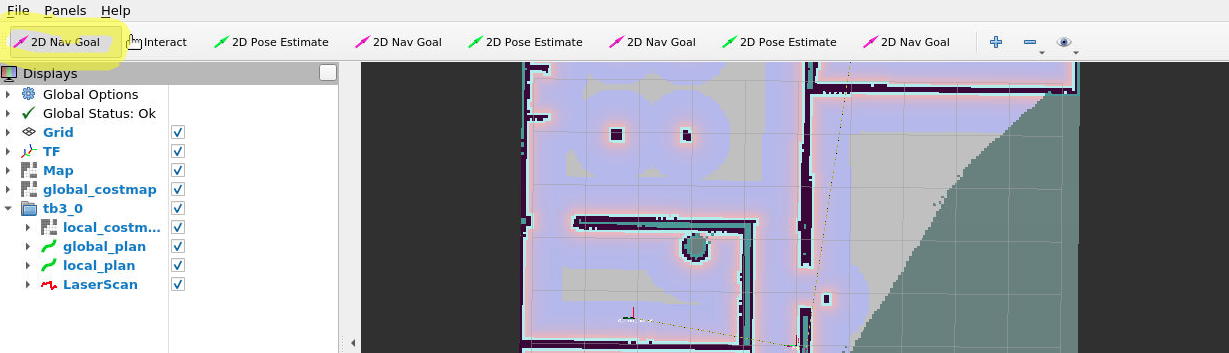

In [ ]:
i = 0
def get_config_goal(data):
    global i
    print("-------------------- Wskazany cel id = {:d}  ------------------".format(i))
    print(data)
    i += 1

In [ ]:
from geometry_msgs.msg import PoseStamped
my_goal = rospy.Subscriber("/config/goal",PoseStamped,get_config_goal)

In [ ]:
!rostopic info /config/goal

In [ ]:
!rosmsg info geometry_msgs/PoseStamped

In [ ]:
!rosmsg info geometry_msgs/Pose

## Zadania
### Zadanie na 3
Utworzenie Publishera dla jednego z robotów, na którym wysłany będzie cel. Wiadomość należy wysłać dla robota tb3_0, tb3_1 lub tb3_2 na topicu /nazwa_robota/move_base_simple/goal

1. Sprawdzić typ wiadomości
2. zaimportować typ wiadomości
3. Zebrać współrzędne punktu
4. Utworzyć publsihera
5. Utworzyć i wysłać wiadomość

### Zadanie na 4
Utworzyć subscribera wyświetlającego wartość rezultatu z topicu dla wybranego robota (/nazwa_robota/move_base/result). 

1. Sprawdzić typ wiadomości
2. Zimportować typ wiadomości
3. utworzyć funkcje wyswietlajaca status bedacy wynikiem zadania dojazdu do punktu
4. utworzyc subscribera

Kolejne punkty na potrzeby testów można wysyłać już z poziomu interfejsu, a nie Publishera z zadania 3-ego

### Zadanie na 5
Utworzyć funkcję symulującą rozładowanie baterii w robotach wraz z upływem czasu i **publikującą informację na topicach**. Korzystając z przykładu (1.1):

http://wiki.ros.org/ROS/Tutorials/WritingPublisherSubscriber%28python%29

należy utworzyć taką funkcję tak, aby w czasie ciągle dokonywane było rozładowanie baterii. Do wysłania poziomu naładowania baterii użyć wiadomości typu Vector3 z geometry_msgs. Kolejno na polach x,y,z powinien się znaleźć poziom naładowania baterii na robotach tb3_0, tb3_1, tb3_2.